# YOLOv8 Egyptian License Plate Detector — Professional Training
- Using Labeled Dataset from `Vehicles` & `Vehicles Labeling` folders.

In [11]:
!pip install ultralytics opencv-python numpy matplotlib Pillow

In [12]:
import os, shutil, random, glob
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO
%matplotlib inline

# --- CONFIG --- 
IMAGES_DIR = r"C:\Users\moman\Desktop\Egyptian License Plates\Egyptian License Plates Dataset\EALPR Vechicles dataset\Vehicles"
LABELS_DIR = r"C:\Users\moman\Desktop\Egyptian License Plates\Egyptian License Plates Dataset\EALPR Vechicles dataset\Vehicles Labeling"
PROJECT_DIR = "yolo_pro_training"
MODEL_SAVE  = "models/yolo_plate_pro.pt"

os.makedirs("models", exist_ok=True)
os.makedirs(PROJECT_DIR, exist_ok=True)

print(f"Found {len(glob.glob(os.path.join(IMAGES_DIR, '*.jpg')))} images")
print(f"Found {len(glob.glob(os.path.join(LABELS_DIR, '*.txt')))} labels")

Found 2085 images
Found 2088 labels


### 1. Data Structuring (Split Train/Val)
YOLO expects a specific folder structure: `images/train`, `images/val`, `labels/train`, `labels/val`.

In [13]:
def prepare_yolo_data(images_path, labels_path, output_base, split_ratio=0.8):
    # Create folders
    for sub in ['images/train', 'images/val', 'labels/train', 'labels/val']:
        os.makedirs(os.path.join(output_base, sub), exist_ok=True)

    image_files = sorted(glob.glob(os.path.join(images_path, "*.jpg")))
    random.seed(42)
    random.shuffle(image_files)

    split_idx = int(len(image_files) * split_ratio)
    train_files = image_files[:split_idx]
    val_files = image_files[split_idx:]

    def copy_pair(files, subset):
        count = 0
        for img_p in files:
            name = os.path.basename(img_p).split('.')[0]
            label_p = os.path.join(labels_path, name + ".txt")
            
            if os.path.exists(label_p):
                # Copy image
                shutil.copy(img_p, os.path.join(output_base, 'images', subset, os.path.basename(img_p)))
                # Copy label
                shutil.copy(label_p, os.path.join(output_base, 'labels', subset, name + ".txt"))
                count += 1
        return count

    print(f"Moving {copy_pair(train_files, 'train')} pairs to TRAIN")
    print(f"Moving {copy_pair(val_files, 'val')} pairs to VAL")

prepare_yolo_data(IMAGES_DIR, LABELS_DIR, PROJECT_DIR)

Moving 1668 pairs to TRAIN
Moving 417 pairs to VAL


### 2. Create dataset.yaml

In [14]:
yaml_content = f"""
path: {os.path.abspath(PROJECT_DIR)}
train: images/train
val: images/val

names:
  0: plate
"""
with open(os.path.join(PROJECT_DIR, "dataset.yaml"), "w") as f:
    f.write(yaml_content.strip())
print("dataset.yaml created.")

dataset.yaml created.


### 3. Verify Labels (Visualize Bounding Boxes)

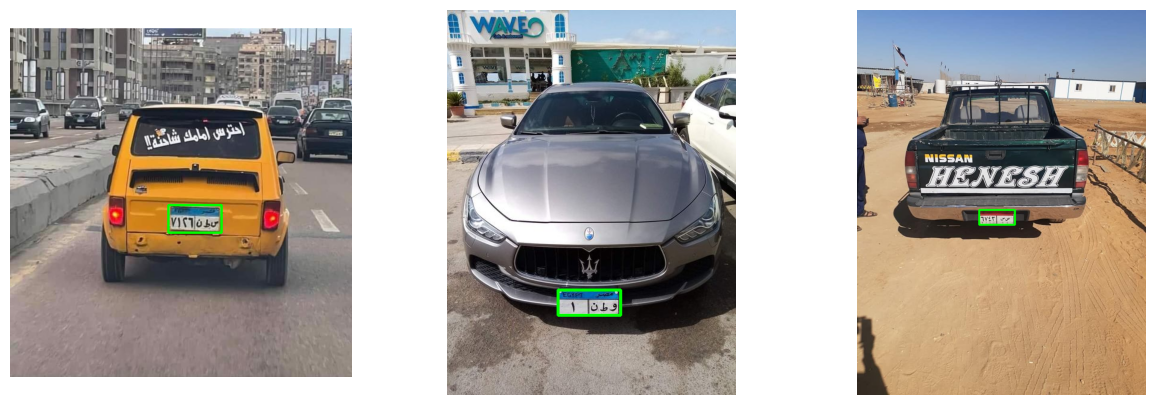

In [15]:
def draw_bbox(img_path, label_path):
    img = cv2.imread(img_path)
    h, w, _ = img.shape
    with open(label_path, 'r') as f:
        for line in f.readlines():
            cls, x, y, bw, bh = map(float, line.split())
            x1, y1 = int((x - bw/2) * w), int((y - bh/2) * h)
            x2, y2 = int((x + bw/2) * w), int((y + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

train_imgs = glob.glob(os.path.join(PROJECT_DIR, "images/train/*.jpg"))[:3]
plt.figure(figsize=(15, 5))
for i, img_p in enumerate(train_imgs):
    lbl_p = img_p.replace("images", "labels").replace(".jpg", ".txt")
    plt.subplot(1, 3, i+1)
    plt.imshow(draw_bbox(img_p, lbl_p))
    plt.axis('off')
plt.show()

### 4. Start Training
We will use YOLOv8n (Nano) for speed, but train it specifically on your data.

In [18]:
import os
import torch
from ultralytics import YOLO

# Ensure paths are absolute and the YAML file exists
yaml_path = os.path.abspath(os.path.join(PROJECT_DIR, "dataset.yaml"))

# Initialize the YOLOv8 Nano model
model = YOLO('yolov8n.pt')

# Start training on your custom Egyptian dataset
results = model.train(
    data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=8,           # Reduced batch size to prevent Out-of-Memory (OOM) errors
    name='egypt_plate_detector',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    workers=0          # Crucial for Windows to prevent multiprocessing errors
)


Ultralytics 8.4.41  Python-3.13.5 torch-2.10.0+cpu CPU (12th Gen Intel Core i7-12650H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\moman\Desktop\Egyptian License Plates\phase2\yolo_pro_training\dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=egypt_plate_detector-2, nbs=64, nms=False, op

KeyboardInterrupt: 

### 5. Save the PRO Model

In [ ]:
import os, shutil
best_path = os.path.join(results.save_dir, 'weights', 'best.pt')
if os.path.exists(best_path):
    shutil.copy(best_path, MODEL_SAVE)
    print(f" SUCCESS! Professional Model saved to: {MODEL_SAVE}")
else:
    print(" Training results not found in expected directory.")

### 6. Test on a New Image

In [ ]:
model = YOLO(MODEL_SAVE)
val_imgs = glob.glob(os.path.join(PROJECT_DIR, "images/val/*.jpg"))[:1]
for img_p in val_imgs:
    res = model(img_p)
    res[0].show()
    # Crop for visual confirmation
    if res[0].boxes:
        box = res[0].boxes[0].xyxy[0].cpu().numpy()
        img = cv2.imread(img_p)
        crop = img[int(box[1]):int(box[3]), int(box[0]):int(box[2])]
        plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        plt.title("This crop will be sent to CNN")
        plt.show()